In [61]:
!pip install -q \
groq \
python-dotenv \
sentence-transformers \
faiss-cpu \
GitPython \
networkx \
matplotlib \
pandas \
numpy

In [62]:
import os
import json
import time
import uuid
import pickle
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from groq import Groq
from sentence_transformers import SentenceTransformer
import faiss

In [63]:


client = Groq(
    api_key=GROQ_API_KEY
)

MODEL = "llama-3.3-70b-versatile"

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

print("✅ Groq Client Initialized")
print("✅ Embedding Model Loaded")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✅ Groq Client Initialized
✅ Embedding Model Loaded


In [64]:
response = client.chat.completions.create(
    model=MODEL,
    messages=[
        {
            "role": "user",
            "content": "Introduce yourself in one sentence."
        }
    ]
)

print(response.choices[0].message.content)

I'm an artificial intelligence language model designed to assist and communicate with users in a helpful and informative way, and I'm here to provide information and answer your questions to the best of my abilities.


In [65]:
@dataclass
class AgentState:

    issue: str

    repository_path: str = ""

    planner_output: Dict[str, Any] = field(default_factory=dict)

    analyzer_output: Dict[str, Any] = field(default_factory=dict)

    retrieved_context: List = field(default_factory=list)

    generated_fix: str = ""

    validation_report: Dict[str, Any] = field(default_factory=dict)

    guardian_report: Dict[str, Any] = field(default_factory=dict)

    confidence: float = 0.0

    history: List = field(default_factory=list)

In [66]:
import json

def ask_llm(prompt: str,
            system_prompt: str = "You are an expert software engineer.",
            temperature: float = 0.2):

    response = client.chat.completions.create(
        model=MODEL,
        temperature=temperature,
        messages=[
            {
                "role": "system",
                "content": system_prompt
            },
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    return response.choices[0].message.content

In [67]:
def parse_json(text: str):

    try:
        return json.loads(text)

    except Exception:

        try:
            start = text.find("{")
            end = text.rfind("}") + 1

            return json.loads(text[start:end])

        except Exception:

            return {
                "error": "Invalid JSON",
                "raw_output": text
            }

In [68]:
class AgentLogger:

    def __init__(self):
        self.logs = []

    def log(self, agent, message):

        entry = {
            "time": time.strftime("%H:%M:%S"),
            "agent": agent,
            "message": message
        }

        self.logs.append(entry)

    def dataframe(self):

        return pd.DataFrame(self.logs)


logger = AgentLogger()

In [69]:
dimension = 384

memory_index = faiss.IndexFlatL2(dimension)

memory_texts = []

memory_metadata = []

In [70]:
def add_memory(text, metadata=None):

    embedding = embedding_model.encode([text])

    memory_index.add(
        np.array(embedding).astype("float32")
    )

    memory_texts.append(text)

    memory_metadata.append(metadata)

In [71]:
def retrieve_memory(query, top_k=5):

    if len(memory_texts) == 0:
        return []

    query_embedding = embedding_model.encode([query])

    distances, indices = memory_index.search(
        np.array(query_embedding).astype("float32"),
        top_k
    )

    results = []

    for idx in indices[0]:

        if idx < len(memory_texts):

            results.append({

                "text": memory_texts[idx],

                "metadata": memory_metadata[idx]

            })

    return results

In [72]:
def save_memory(filename="memory.pkl"):

    data = {

        "texts": memory_texts,

        "metadata": memory_metadata

    }

    with open(filename, "wb") as f:
        pickle.dump(data, f)

    faiss.write_index(memory_index, "memory.index")

In [73]:
def load_memory(filename="memory.pkl"):

    global memory_index
    global memory_texts
    global memory_metadata

    if not Path(filename).exists():

        print("No previous memory found.")

        return

    with open(filename, "rb") as f:

        data = pickle.load(f)

    memory_texts = data["texts"]

    memory_metadata = data["metadata"]

    memory_index = faiss.read_index("memory.index")

    print("Memory Loaded")

In [74]:
import os

def list_files(repo_path, extensions=None):
    """
    Recursively list files in a repository.
    """
    files = []

    for root, _, filenames in os.walk(repo_path):
        for file in filenames:

            if extensions:
                if any(file.endswith(ext) for ext in extensions):
                    files.append(os.path.join(root, file))
            else:
                files.append(os.path.join(root, file))

    return files


def read_file(path):
    """
    Read a file safely.
    """
    try:
        with open(path, "r", encoding="utf-8") as f:
            return f.read()

    except Exception as e:
        return f"ERROR: {e}"


def search_keyword(repo_path, keyword):

    results = []

    for file in list_files(repo_path):

        try:

            text = read_file(file)

            if keyword.lower() in text.lower():

                results.append(file)

        except:
            pass

    return results

In [75]:
import ast

TOOLS = {
    "list_files": list_files,
    "read_file": read_file,
    "search_keyword": search_keyword,
    "search_function": None,
    "search_imports": None,
    "finish_reasoning": None
}


def search_function(repo_path, function_name):

    results = []

    for file in list_files(repo_path, [".py"]):

        try:

            tree = ast.parse(read_file(file))

            for node in ast.walk(tree):

                if isinstance(node, ast.FunctionDef):

                    if node.name == function_name:

                        results.append(file)

        except:
            pass

    return results


def search_imports(repo_path):

    imports = {}

    for file in list_files(repo_path, [".py"]):

        try:

            tree = ast.parse(read_file(file))

            current = []

            for node in ast.walk(tree):

                if isinstance(node, ast.Import):

                    current.extend(
                        [alias.name for alias in node.names]
                    )

                elif isinstance(node, ast.ImportFrom):

                    current.append(node.module)

            imports[file] = current

        except:
            pass

    return imports


TOOLS["search_function"] = search_function
TOOLS["search_imports"] = search_imports

In [76]:
TOOL_DESCRIPTIONS = """
You are a software debugging agent.

Available tools

1. list_files
Arguments:
{
"repo_path":"..."
}

2. read_file
Arguments:
{
"path":"..."
}

3. search_keyword
Arguments:
{
"repo_path":"...",
"keyword":"..."
}

4. search_function
Arguments:
{
"repo_path":"...",
"function_name":"..."
}

5. search_imports
Arguments:
{
"repo_path":"..."
}

6. finish_reasoning

When you have enough information,
select finish_reasoning.

Return ONLY JSON.

Example

{
"tool":"search_keyword",
"arguments":{
"repo_path":"./repo",
"keyword":"login"
}
}
"""

In [77]:
def select_next_tool(state):

    history = json.dumps(
        state.history,
        indent=2
    )

    prompt = f"""
Issue

{state.issue}

Previous observations

{history}

{TOOL_DESCRIPTIONS}

Choose the NEXT tool.

Return JSON.
"""

    return parse_json(
        ask_llm(prompt)
    )

In [78]:
def execute_tool_call(tool_json):

    tool = tool_json["tool"]

    if tool == "finish_reasoning":

        return None

    arguments = tool_json.get(
        "arguments",
        {}
    )

    function = TOOLS[tool]

    return function(**arguments)

In [79]:
class ToolAgent:

    def __init__(self):

        self.max_iterations = 8

    def run(self, state):

        logger.log(
            "ToolAgent",
            "Started"
        )

        state.history = []

        for i in range(self.max_iterations):

            tool_json = select_next_tool(state)

            tool = tool_json["tool"]

            logger.log(
                "ToolAgent",
                f"Iteration {i+1}: {tool}"
            )

            if tool == "finish_reasoning":

                logger.log(
                    "ToolAgent",
                    "Finished reasoning."
                )

                break

            observation = execute_tool_call(
                tool_json
            )

            state.history.append({

                "tool": tool,

                "arguments": tool_json.get(
                    "arguments",
                    {}
                ),

                "observation": str(observation)[:4000]

            })

        return state

In [80]:
class PlannerAgent:

    def run(self, state: AgentState):

        logger.log("Planner", "Planning started.")

        prompt = f"""
You are an expert software architect.

Analyze the following GitHub Issue.

Issue:
{state.issue}

Return ONLY valid JSON.

Required format:

{{
    "problem": "...",
    "possible_root_cause": "...",
    "possible_files": [],
    "strategy": [],
    "tests_needed":[]
}}
"""

        response = ask_llm(prompt)

        result = parse_json(response)

        state.planner_output = result

        logger.log("Planner", "Planning completed.")

        return state

In [81]:
class RepositoryAnalyzer:

    def run(self, state: AgentState):

        logger.log("Analyzer", "Repository analysis started.")

        repo_files = list_files(
            state.repository_path,
            [".py", ".js", ".ts", ".java", ".cpp"]
        )

        summary = []

        for file in repo_files[:30]:

            try:

                content = read_file(file)

                summary.append({

                    "file": file,

                    "lines": len(content.splitlines()),

                    "characters": len(content)

                })

            except:
                pass

        state.analyzer_output = {

            "total_files": len(repo_files),

            "summary": summary

        }

        logger.log("Analyzer", "Repository analysis completed.")

        return state

In [82]:
class RetrieverAgent:

    def run(self, state: AgentState):

        logger.log("Retriever", "Searching semantic memory.")

        retrieved = retrieve_memory(state.issue)

        state.retrieved_context = retrieved

        logger.log(
            "Retriever",
            f"Retrieved {len(retrieved)} memory entries."
        )

        return state

In [83]:
class FixGenerator:

    def run(self, state):

        logger.log("Generator", "Generating solution.")

        prompt = f"""
You are a Senior Software Engineer.

Your job is to generate a fix using ONLY the investigation history.

GitHub Issue

{state.issue}

-------------------------------------------------

Planner Output

{json.dumps(state.planner_output, indent=2)}

-------------------------------------------------

Tool Investigation History

{json.dumps(state.history, indent=2)}

-------------------------------------------------

Relevant Memory

{json.dumps(state.retrieved_context, indent=2)}

-------------------------------------------------

Generate a complete response containing:

1. Root Cause

2. Explanation

3. Files To Modify

4. Code Diff

5. Why this fix works

Return markdown.
"""

        state.generated_fix = ask_llm(prompt)

        logger.log("Generator", "Solution Generated.")

        return state

In [84]:
class ValidatorAgent:

    def run(self, state):

        logger.log("Validator", "Validating Patch")

        prompt = f"""
Review this software patch.

Issue

{state.issue}

---------------------------------

Generated Patch

{state.generated_fix}

---------------------------------

Return ONLY JSON.

{{
    "confidence":90,
    "approved":true,
    "strengths":[],
    "weaknesses":[],
    "missing_cases":[]
}}
"""

        response = ask_llm(prompt)

        result = parse_json(response)

        state.validation_report = result

        state.confidence = result.get(
            "confidence",
            0
        )

        logger.log(
            "Validator",
            f"Confidence={state.confidence}"
        )

        return state

In [85]:
class ReflectionAgent:

    def __init__(self):

        self.max_retry = 3

        self.threshold = 85

    def run(self, state):

        retry = 0

        while state.confidence < self.threshold:

            logger.log(
                "Reflection",
                f"Retry {retry+1}"
            )

            state = FixGenerator().run(state)

            state = ValidatorAgent().run(state)

            retry += 1

            if retry >= self.max_retry:

                break

        return state

In [86]:
class GuardianAgent:

    def run(self, state):

        logger.log(
            "Guardian",
            "Independent Review"
        )

        prompt = f"""
You are a Staff Engineer.

Review this generated patch.

Issue

{state.issue}

---------------------------------

Patch

{state.generated_fix}

---------------------------------

Validation

{json.dumps(state.validation_report,indent=2)}

Return ONLY JSON.

{{
    "approved":true,
    "risk":"LOW",
    "recommendation":"",
    "confidence":95
}}
"""

        response = ask_llm(prompt)

        state.guardian_report = parse_json(response)

        logger.log(
            "Guardian",
            "Completed"
        )

        return state

In [87]:
class BugFixPipeline:

    def __init__(self):

        self.planner = PlannerAgent()

        self.tool_agent = ToolAgent()

        self.analyzer = RepositoryAnalyzer()

        self.retriever = RetrieverAgent()

        self.generator = FixGenerator()

        self.validator = ValidatorAgent()

        self.reflection = ReflectionAgent()

        self.guardian = GuardianAgent()

    def run(self, state):

        state = self.planner.run(state)

        state = self.tool_agent.run(state)

        state = self.analyzer.run(state)

        state = self.retriever.run(state)

        state = self.generator.run(state)

        state = self.validator.run(state)

        state = self.reflection.run(state)

        state = self.guardian.run(state)

        return state

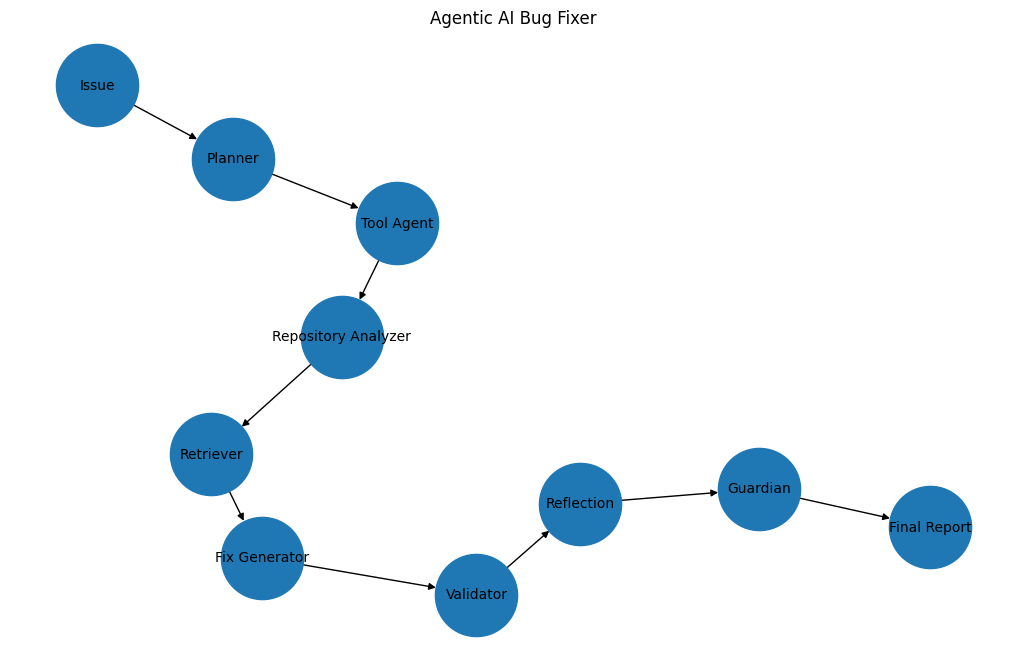

In [88]:
graph = nx.DiGraph()

graph.add_edges_from([

    ("Issue","Planner"),

    ("Planner","Tool Agent"),

    ("Tool Agent","Repository Analyzer"),

    ("Repository Analyzer","Retriever"),

    ("Retriever","Fix Generator"),

    ("Fix Generator","Validator"),

    ("Validator","Reflection"),

    ("Reflection","Guardian"),

    ("Guardian","Final Report")

])

plt.figure(figsize=(13,8))

pos = nx.spring_layout(graph, seed=42)

nx.draw_networkx(
    graph,
    pos,
    node_size=3500,
    font_size=10,
    arrows=True
)

plt.title("Agentic AI Bug Fixer")

plt.axis("off")

plt.show()

In [89]:
issue = """
The login endpoint crashes when password is empty.
Instead of returning HTTP 400,
it throws HTTP 500.
"""

repo_path = "./sample_repo"

state = AgentState(
    issue=issue,
    repository_path=repo_path
)

In [90]:
pipeline = BugFixPipeline()

final_state = pipeline.run(state)

In [91]:
print("="*80)
print("PLANNER OUTPUT")
print("="*80)

print(json.dumps(
    final_state.planner_output,
    indent=2
))

print("\n")

print("="*80)
print("TOOL HISTORY")
print("="*80)

print(json.dumps(
    final_state.history,
    indent=2
))

print("\n")

print("="*80)
print("GENERATED FIX")
print("="*80)

print(final_state.generated_fix)

print("\n")

print("="*80)
print("VALIDATION")
print("="*80)

print(json.dumps(
    final_state.validation_report,
    indent=2
))

print("\n")

print("="*80)
print("GUARDIAN")
print("="*80)

print(json.dumps(
    final_state.guardian_report,
    indent=2
))

PLANNER OUTPUT
{
  "problem": "Login endpoint crashes with HTTP 500 when password is empty instead of returning HTTP 400",
  "possible_root_cause": "Insufficient input validation or error handling in the login endpoint",
  "possible_files": [
    "login_controller.py",
    "user_service.py",
    "validation_utils.py"
  ],
  "strategy": [
    "Review input validation logic in the login endpoint",
    "Check for missing or incorrect error handling mechanisms",
    "Verify that the endpoint correctly handles empty password scenarios"
  ],
  "tests_needed": [
    "Unit test for login endpoint with empty password",
    "Integration test for login endpoint with invalid input",
    "Error handling test for login endpoint with unexpected input"
  ]
}


TOOL HISTORY
[
  {
    "tool": "search_keyword",
    "arguments": {
      "repo_path": "./repo",
      "keyword": "login"
    },
    "observation": "[]"
  },
  {
    "tool": "search_keyword",
    "arguments": {
      "repo_path": "./repo",
     

In [92]:
logger.dataframe()

,time,agent,message
0,16:56:56,Planner,Planning started.
1,16:56:57,Planner,Planning completed.
2,16:56:57,ToolAgent,Started
3,16:56:57,ToolAgent,Iteration 1: search_keyword
4,16:56:58,ToolAgent,Iteration 2: search_keyword
5,16:56:58,ToolAgent,Iteration 3: search_keyword
6,16:56:58,ToolAgent,Iteration 4: search_function
7,16:56:58,ToolAgent,Iteration 5: search_function
8,16:56:59,ToolAgent,Iteration 6: search_function
9,16:56:59,ToolAgent,Iteration 7: search_keyword


In [93]:
if final_state.guardian_report.get("approved", False):

    add_memory(

        final_state.issue,

        {

            "history": final_state.history,

            "planner": final_state.planner_output,

            "validation": final_state.validation_report

        }

    )

    save_memory()

    print("Memory Updated")

else:

    print("Patch Rejected")

Memory Updated


In [ ]:
# ==========================
# AGENTIC AI BUG FIXER DEMO
# ==========================

# Enter your GitHub issue here
issue = """
Title: Login API returns HTTP 500

Description:
The login endpoint crashes whenever the password field is empty.

Expected Behavior:
Return HTTP 400 with:
'Password cannot be empty.'

Observed Behavior:
Returns HTTP 500 Internal Server Error.

Steps to Reproduce:
1. POST /login
2.
{
    "username":"john",
    "password":""
}

Priority:
High

Please investigate the repository, identify the root cause,
find the affected files, and generate a patch.
"""

# Change this to your repository
repo_path = "https://github.com/Guru3536/customer-segmentation-churn-prediction"

# Create Agent State
state = AgentState(
    issue=issue,
    repository_path=repo_path
)

# Run Pipeline
pipeline = BugFixPipeline()

print("=" * 80)
print("RUNNING AGENT...")
print("=" * 80)

final_state = pipeline.run(state)

print("\n" + "=" * 80)
print("PLANNER OUTPUT")
print("=" * 80)
print(json.dumps(final_state.planner_output, indent=2))

print("\n" + "=" * 80)
print("TOOL INVESTIGATION HISTORY")
print("=" * 80)

for i, step in enumerate(final_state.history, 1):

    print(f"\nSTEP {i}")

    print("-" * 60)

    print("Tool:")
    print(step["tool"])

    print("\nArguments:")
    print(step["arguments"])

    print("\nObservation:")
    print(step["observation"])

print("\n" + "=" * 80)
print("GENERATED FIX")
print("=" * 80)
print(final_state.generated_fix)

print("\n" + "=" * 80)
print("VALIDATION REPORT")
print("=" * 80)
print(json.dumps(final_state.validation_report, indent=2))

print("\n" + "=" * 80)
print("GUARDIAN REVIEW")
print("=" * 80)
print(json.dumps(final_state.guardian_report, indent=2))

print("\n" + "=" * 80)
print("CONFIDENCE")
print("=" * 80)
print(final_state.confidence)

print("\n" + "=" * 80)
print("EXECUTION LOGS")
print("=" * 80)

display(logger.dataframe())

RUNNING AGENT...
